### Import libraries

In [22]:
import pandas as pd
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel
from darts.dataprocessing.transformers import StaticCovariatesTransformer
import numpy as np
import torch
import matplotlib.pyplot as plt

In [49]:
from pytorch_lightning.callbacks import Callback

class LossLogger(Callback):
    """
    A PyTorch Lightning callback to record training and validation losses 
    at the end of every epoch for custom plotting or analysis.
    """
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        # Retrieve train_loss from callback_metrics
        train_loss = trainer.callback_metrics.get("train_loss")
        
        if train_loss is not None:
            # detach() ensures we don't keep the computation graph in memory
            # cpu() ensures it works regardless of whether you're on GPU or CPU
            self.train_losses.append(float(train_loss.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module):
        # Retrieve val_loss from callback_metrics
        val_loss = trainer.callback_metrics.get("val_loss")
        
        if val_loss is not None:
            self.val_losses.append(float(val_loss.detach().cpu()))

### Read the data

In [24]:
pandas_df = pd.read_csv(r"all_series_data.csv",index_col = ['MONTH_OF_SALE'],parse_dates=True)

In [25]:
pandas_df["DEALER_CODE"] = pandas_df["DEALER_CODE"].astype('str')

In [26]:
pandas_df.index.min()

Timestamp('2023-04-01 00:00:00')

In [27]:
pandas_df["DEALER_CITY"].dtypes

dtype('O')

In [28]:
#Extracting type of columns according to the datatypes
# 1. Targets/Metrics (The numbers we want to predict)
target_cols = pandas_df.select_dtypes(include=['number']).columns.tolist()
target_cols.append('PARENT_DEALER_CODE_MODEL_FAMILY')

# 2. Time Dimension
time_cols = pandas_df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

# 3. Static/Categorical Covariates (The identifiers)
# We exclude numbers and dates to find the "ID" strings
static_cols = pandas_df.select_dtypes(exclude=['number', 'datetime', 'datetime64']).columns.tolist()

print(f"Targets: {target_cols}")
print(f"Time Column: {time_cols}")
print(f"Static Identifiers: {static_cols}")

Targets: ['NUM_FESTIVE_DAYS_MONTH', 'FESTIVE_PHASE_I', 'FESTIVE_PHASE_II', 'FESTIVE_PHASE_III', 'TOTAL_DAYS_FESTIVE_PHASE_I', 'TOTAL_DAYS_FESTIVE_PHASE_II', 'TOTAL_DAYS_FESTIVE_PHASE_III', 'TOTAL_DAYS_PITRU_PAKSH', 'PROP_FESTIVE_PHASE_I', 'PROP_EVENT_FESTIVE_PHASE_I', 'PROP_FESTIVE_PHASE_II', 'PROP_EVENT_FESTIVE_PHASE_II', 'PROP_FESTIVE_PHASE_III', 'PROP_EVENT_FESTIVE_PHASE_III', 'PROP_PITRU_PAKSH', 'PROP_EVENT_PITRU_PAKSH', 'NET_SALES', 'AKSHAYA_TRITIYA_DAYS', 'BHAI_DOOJ_DAYS', 'BUDDHA_PURNIMA_DAYS', 'CHHATH_PUJA_DAYS', 'DHANTERAS_DAYS', 'DIWALI_DAYS', 'DUSSEHRA_(VIJAYADASHAMI)_DAYS', 'EID_UL_FITR_DAYS', 'GANESH_CHATURTHI_DAYS', 'GANGA_DUSSEHRA_DAYS', 'GOVARDHAN_POOJA_DAYS', 'GURU_PURNIMA_DAYS', 'HANUMAN_JAYANTI_DAYS', 'HARTALIK_TEEJ_DAYS', 'HOLI_DAYS', 'HOLIKA_DAHAN_DAYS', 'JAGANNATH_RATHYATRA_DAYS', 'JANMASHTAMI_DAYS', 'KARWA_CHAUTH_DAYS', 'LOHRI_DAYS', 'MAHA_SHIVARATRI_DAYS', 'MAKAR_SANKRANTI_PONGAL_DAYS', 'NAG_PANCHAMI_DAYS', 'NAVRATRI_DAYS', 'NEW_YEAR_DAYS', 'ONAM_DAYS', 'PITRAPA

In [29]:
#Separating the covariates
target_col = ["NET_SALES"]

#future covariates
future_covariates = [i for i in target_cols if i!='NET_SALES']

#actual_static_cols
actual_static_cols = [i for i in static_cols if i!='PARENT_DEALER_CODE_MODEL_FAMILY']

In [30]:
#since variables like MODEL_FAMILY,BRAKE_VARIANT,IGNITION_TYPE,WHEEL_TYPE,BIKE_COLOUR are mostly same for all the top 10 series, will be removing them from the static covariates'
static_covariates = [i for i in actual_static_cols if i not in ['MODEL_FAMILY','BRAKE_VARIANT','IGNITION_TYPE','WHEEL_TYPE','BIKE_COLOUR','DEALER_CODE']]
static_covariates

['DEALER_CITY', 'X_CITY_CATEGORY']

In [31]:
# Function to encode the year as a normalized value
def encode_year(idx):
  return (idx.year - 2000) / 50

def encode_days_in_month(index):
  return index.days_in_month.to_numpy().reshape(-1,1)

# Set up the add_encoders dictionary to specify how different time-related encoders and transformers should be applied
add_encoders = {
    'cyclic': {'past': ['month'], 'future': ['month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {
        'past': [encode_year, encode_days_in_month],
        'future': [encode_year, encode_days_in_month]
    },
    'transformer': Scaler()
}

### Preparing data for Darts 

In [32]:
#Step 1 - Sorting the dataframe by date
pandas_df.reset_index().sort_values(by=["PARENT_DEALER_CODE_MODEL_FAMILY","MONTH_OF_SALE"]).set_index("MONTH_OF_SALE",inplace=True)

In [33]:
static_covariates

['DEALER_CITY', 'X_CITY_CATEGORY']

In [34]:
#Step 2 - Separating the static covariates and NET_SALES column
pandas_df_with_target_and_static_covariates = pandas_df.loc[:,['PARENT_DEALER_CODE_MODEL_FAMILY','NET_SALES']+static_covariates]
pandas_df_with_target_and_static_covariates.head()

,PARENT_DEALER_CODE_MODEL_FAMILY,NET_SALES,DEALER_CITY,X_CITY_CATEGORY
MONTH_OF_SALE,,,,
2023-04-01,11211_XPULSE_DISC<>SELF<>SPOKE<>SPORTS RED,1.0,HAZARIBAG,UNSPECIFIED
2023-04-01,11682_PLEASURE+_DRUM<>SELF<>CAST<>BLUE,1.0,SAMBHAL,URBAN
2023-04-01,11681_SPLENDOR+_DRUM<>SELF<>CAST<>PRIME RED,2.0,KOLKATA,URBAN
2023-04-01,11073_GLAMOUR_DRUM<>SELF<>CAST<>BLUE BLACK,0.0,KURNOOL,RURAL
2023-04-01,11641_DESTINI_DRUM<>SELF<>CAST<>BROWN,0.0,CHANDIKHOLE,RURAL


In [35]:
#Step 3 - Separating the future covariates
pandas_df_with_future_covariates = pandas_df.loc[:,future_covariates]
pandas_df_with_future_covariates.head()

,NUM_FESTIVE_DAYS_MONTH,FESTIVE_PHASE_I,FESTIVE_PHASE_II,FESTIVE_PHASE_III,TOTAL_DAYS_FESTIVE_PHASE_I,TOTAL_DAYS_FESTIVE_PHASE_II,TOTAL_DAYS_FESTIVE_PHASE_III,TOTAL_DAYS_PITRU_PAKSH,PROP_FESTIVE_PHASE_I,PROP_EVENT_FESTIVE_PHASE_I,...,NAVRATRI_DAYS,NEW_YEAR_DAYS,ONAM_DAYS,PITRAPAKSHA_DAYS,RAKSHA_BANDHAN_DAYS,REPUBLIC_DAY_DAYS,VASANT_PANCHAMI_DAYS,VISHWAKARMA_PUJA_DAYS,MARRIAGE_DAYS,PARENT_DEALER_CODE_MODEL_FAMILY
MONTH_OF_SALE,,,,,,,,,,,,,,,,,,,,,
2023-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11211_XPULSE_DISC<>SELF<>SPOKE<>SPORTS RED
2023-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11682_PLEASURE+_DRUM<>SELF<>CAST<>BLUE
2023-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11681_SPLENDOR+_DRUM<>SELF<>CAST<>PRIME RED
2023-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11073_GLAMOUR_DRUM<>SELF<>CAST<>BLUE BLACK
2023-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11641_DESTINI_DRUM<>SELF<>CAST<>BROWN


In [36]:
#Step 4 - Creating the darts timeseries object for target and static covariates
darts_df_with_static_covariates = TimeSeries.from_group_dataframe(df=pandas_df_with_target_and_static_covariates,
                                                                  group_cols=["PARENT_DEALER_CODE_MODEL_FAMILY"],
                                                                  static_cols=static_covariates,value_cols=["NET_SALES"],freq='MS')


In [37]:
darts_df_with_static_covariates[0]

,NET_SALES
MONTH_OF_SALE,
2023-04-01,4.0
2023-05-01,6.0
2023-06-01,4.0
2023-07-01,5.0
2023-08-01,3.0
...,...
2025-11-01,2.0
2025-12-01,1.0
2026-01-01,5.0


In [38]:
#Step 5 - Creating the darts timeseries object with future covariates

#Removing PARENT_DEALER_CODE_MODEL_FAMILY from future_covariates
try:
    future_covariates.remove('PARENT_DEALER_CODE_MODEL_FAMILY')
except:
    pass

darts_df_with_future_covariates = TimeSeries.from_group_dataframe(df = pandas_df_with_future_covariates,
                                    group_cols="PARENT_DEALER_CODE_MODEL_FAMILY",
                                    freq = 'MS',
                                    value_cols = future_covariates
                                    )

In [39]:
#Step 5 - Creating train, test, and validation split
#Train set - Apr'23 to Dec'25 
#Val set - Jan'26 to Mar'26 


train_list = []
val_list = []

for ts in darts_df_with_static_covariates:
    train = ts.slice(pd.Timestamp('2023-04-01'), pd.Timestamp('2025-12-01'))
    val = ts.slice(pd.Timestamp('2025-01-01'), pd.Timestamp('2026-03-01'))
    
    train_list.append(train)
    val_list.append(val)

train_future_covariates_list = []
validation_future_covariates_list = []

for ts in darts_df_with_future_covariates:
    train = ts.slice(pd.Timestamp('2023-04-01'), pd.Timestamp('2025-12-01'))
    val = ts.slice(pd.Timestamp('2025-01-01'), pd.Timestamp('2026-03-01'))
    train_future_covariates_list.append(train)
    validation_future_covariates_list.append(val)


    
    

In [40]:
#Step 5 - Scaling
target_scaler = Scaler(n_jobs=-1)
future_covariates_scaler = Scaler(n_jobs=-1)

transformer = StaticCovariatesTransformer(n_jobs=-1)

#Scale the target training data
scaled_target_series = target_scaler.fit_transform(train_list)

scaled_target_series_with_static_covariates_training = transformer.fit_transform(scaled_target_series)



# #Scale the static covariates in training data
# scaled_static_covariates_training = transformer.fit_transform(train_list)

# #Scale the future covariates in training data
# # scaled_future_covariates = future_covariates_scaler.fit_transform(darts_df_with_future_covariates)

scaled_future_covariates_training = future_covariates_scaler.fit_transform(train_future_covariates_list)
scaled_future_covariates_validation = future_covariates_scaler.transform(validation_future_covariates_list)


# #Scale the target validation data
scaled_target_series_validation = target_scaler.transform(val_list)
scaled_target_series_with_static_covariates_validation = transformer.transform(scaled_target_series_validation)

# #Scale the static covariates in validation data
# scaled_static_covariates_validation = transformer.transform(val_list)




In [ ]:
type(target_scaler)

### Modelling

In [41]:
from datetime import datetime
from pytorch_lightning.callbacks import ModelCheckpoint

current_date = datetime.now().strftime("%Y-%m-%d")

# 2. Add it to the filename string
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/",
    filename=f"tft-best-model-{current_date}-{{epoch:02d}}-{{val_loss:.4f}}",
    save_top_k=1,
    mode="min"
)

In [42]:
loss_logger = LossLogger()
model = TFTModel(input_chunk_length=12,output_chunk_length=3,
                 batch_size=512,dropout=0.0,likelihood=None,loss_fn=torch.nn.MSELoss(),
                 n_epochs=100,random_state=42,add_encoders=add_encoders,
                 pl_trainer_kwargs={'callbacks': [loss_logger,checkpoint_callback],
                                    'enable_checkpointing':True})

model.fit(series=scaled_target_series_with_static_covariates_training,
          future_covariates = scaled_future_covariates_training,
          val_series = scaled_target_series_with_static_covariates_validation,
          val_future_covariates=scaled_future_covariates_validation,verbose=True)

trainer = model.trainer
optimizer = trainer.optimizers[0]
current_lr = optimizer.param_groups[0]["lr"]
total_epochs = model.trainer.max_epochs

def title_of_the_plot():
    total_epochs = len(loss_logger.losses)
    
    if total_epochs > 0:
        last_loss = loss_logger.losses[-1]
        return f"Overfitting Debug - lr: {current_lr}, epochs: {total_epochs}, last_loss: {last_loss:.2f}"
    return "Overfitting Debug - No Data"

plt.figure(figsize=(10, 6))
plt.plot(loss_logger.losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title(title_of_the_plot())
plt.grid(True, alpha=0.3) 
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 2000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | trai

Epoch 2:  17%|█▋        | 447/2595 [04:02<19:25,  1.84it/s, train_loss=0.0354, val_loss=0.110] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

### Prediction on best checkpoint

In [70]:
model = TFTModel(
    input_chunk_length=12,
    output_chunk_length=3,
    batch_size=512,
    dropout=0.0,
    likelihood=None,
    loss_fn=torch.nn.MSELoss(),
    n_epochs=100,
    random_state=42,
    add_encoders=add_encoders,
)

In [73]:
from darts.models.forecasting.tft_model import _TFTModule

model.model = _TFTModule.load_from_checkpoint(
    checkpoint_path=r"C:\Users\G0004878\Desktop\TFT_Data\Multi_series\checkpoints\tft-best-model-2026-05-01-epoch=00-val_loss=0.1076.ckpt"
)

In [74]:
model.model.eval()

_TFTModule(
  (criterion): MSELoss()
  (train_criterion): MSELoss()
  (val_criterion): MSELoss()
  (train_metrics): MetricCollection,
    prefix=train_
  )
  (val_metrics): MetricCollection,
    prefix=val_
  )
  (input_embeddings): _MultiEmbedding(
    (embeddings): ModuleDict()
  )
  (static_covariates_vsn): _VariableSelectionNetwork(
    (flattened_grn): _GatedResidualNetwork(
      (resample_norm): _ResampleNorm(
        (resample): _TimeDistributedInterpolation()
        (gate): Sigmoid()
        (norm): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
      )
      (fc1): Linear(in_features=24, out_features=3, bias=True)
      (elu): ELU(alpha=1.0)
      (fc2): Linear(in_features=3, out_features=3, bias=True)
      (gate_norm): _GateAddNorm(
        (glu): _GatedLinearUnit(
          (dropout): MonteCarloDropout(p=0.0, inplace=False)
          (fc): Linear(in_features=3, out_features=6, bias=True)
        )
        (add_norm): _AddNorm(
          (norm): LayerNorm((3,), eps=1e

In [ ]:
# model._fit_called = True
model.model

In [ ]:
model.model

In [77]:
import torch
from darts.dataprocessing.encoders import SequentialEncoder

# 1. Standard Unlocking
model.model.eval()
model._fit_called = True

# 2. THE FIX: Manually build and attach the encoder to the TOP-LEVEL model
# We use the 'add_encoders' you defined in your skeleton
if model.add_encoders is not None:
    # Create the encoder manually
    encoder = SequentialEncoder(
        add_encoders=model.add_encoders,
        input_chunk_length=model.input_chunk_length,
        output_chunk_length=model.output_chunk_length,
    )
    
    # Teach it the time-index from your training data
    # Use 'series' (target) and 'future_covariates'
    encoder.fit(scaled_target_series_with_static_covariates_training, scaled_future_covariates_training)
    
    # Attach it to the model where 'predict()' expects to find it
    model.encoders = encoder

# 3. Predict using torch.no_grad() to avoid that Deepcopy error
with torch.no_grad():
    forecast = model.predict(
        n=3, 
        series=scaled_target_series_with_static_covariates_training, 
        future_covariates=scaled_future_covariates_training
    )

print("Forecast generated successfully!")

AttributeError: '_TFTModule' object has no attribute 'add_encoders'

In [66]:
model = TFTModel.load(r"C:\Users\G0004878\Desktop\TFT_Data\Multi_series\checkpoints\tft-best-model-2026-05-01-epoch=00-val_loss=0.1076.ckpt")

AttributeError: 'dict' object has no attribute '_fit_called'

In [60]:
val_forecast = model.predict(
    n=3, 
    series=scaled_target_series_with_static_covariates_training,      
    future_covariates=scaled_future_covariates_validation)

TypeError: 'NoneType' object is not subscriptable

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 125/125 [00:09<00:00, 13.76it/s]


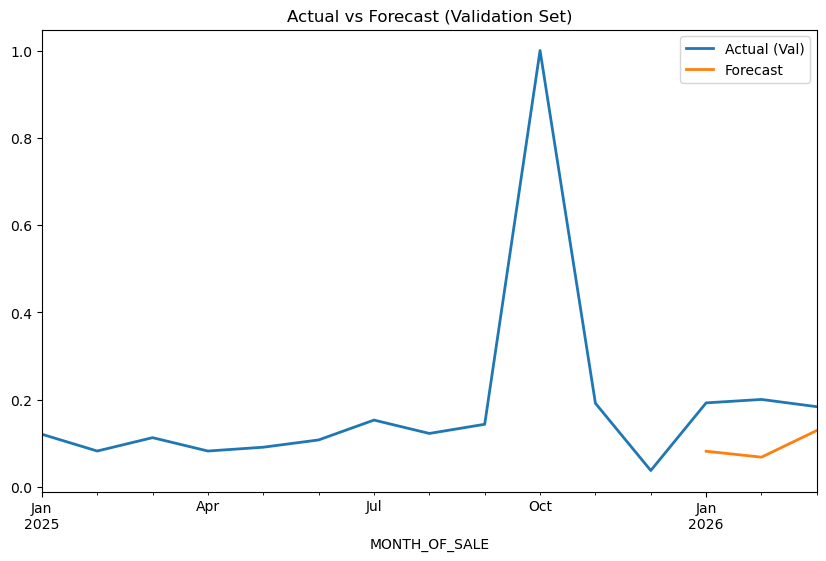

In [ ]:
# Predict the validation period
pred_series = model.predict(n=3, series=scaled_target_series_with_static_covariates_training,
                            future_covariates = scaled_future_covariates_validation)

plt.figure(figsize=(10, 6))
scaled_target_series_with_static_covariates_validation[0].plot(label='Actual (Val)')
pred_series[0].plot(label='Forecast')
plt.title("Actual vs Forecast (Validation Set)")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(loss_logger, model):
    """
    Plots training vs validation loss with dynamic metadata in the title.
    """
    # Extract training metadata from the model trainer
    trainer = model.trainer
    optimizer = trainer.optimizers[0]
    current_lr = optimizer.param_groups[0]["lr"]
    epochs_range = range(1, len(loss_logger.train_losses) + 1)
    
    # Helper to generate descriptive title
    if len(loss_logger.train_losses) > 0:
        title = (
            f"TFT Overfitting Debug | LR={current_lr:.2e} | "
            f"Epochs={len(epochs_range)}\n"
            f"Final Train Loss: {loss_logger.train_losses[-1]:.4f} | "
            f"Final Val Loss: {loss_logger.val_losses[-1]:.4f}"
        )
    else:
        title = "TFT Overfitting Debug (No Data)"

    # Create the plot
    plt.figure(figsize=(10, 6))
    
    plt.plot(epochs_range, loss_logger.train_losses, label="Train Loss", linewidth=2)
    plt.plot(epochs_range, loss_logger.val_losses, label="Validation Loss", linewidth=2, linestyle='--')

    # Formatting
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Execution
plot_training_results(loss_logger, model)

,NET_SALES
MONTH_OF_SALE,
2025-01-01,0.120841
2025-02-01,0.082312
2025-03-01,0.112960
2025-04-01,0.082312
2025-05-01,0.091068
...,...
2025-11-01,0.191769
2025-12-01,0.037653
2026-01-01,0.192644
